# A Multi-class Text Classification with a Custom Transformer Model created from scratch using PyTorch

In [1]:
import gzip
import io
import json
import math
import copy
import pickle
import requests
import string
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from prettytable import PrettyTable

# Emotion dataset for Text Classifiction (6 Classes)
This is a dataset of English Twitter messages with 6 basic emotions: ```sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5)```. This 6 emotions variant of the Emotion Dataset that was used for Emotion Classification (**Saravia et al., 2018**) is meant to be used for educational and research purposes.

This dataset was used for Emotion Classification by understanding the text and building a mechanism capable of capturing and modeling different linguistic nuances and phenomena. As suggested by the Paper, there are linguistic nuances as well as a combination of experiences, knowledge, and belief systems that characterise an Emotion, it felt like a nice candidate for a Multi-class Text Classification Task for a Transformer.

The data is made available in JSON Lines format and uses compression resulting in .jsonl.gz extension. An example json record looks as follows:

```{ "text": "i have been feeling the need to be creative", "label": 1 }```

In [2]:
data_url = "https://huggingface.co/datasets/dair-ai/emotion/resolve/main/data/data.jsonl.gz"

# Applying an Encoder-only Transformer

Since the Paper accompanying Emotion Classification Dataset (Saravia et al., 2018), proposed a semi-supervised, graph-based algorithm to produce rich structural descriptors which serve as the building blocks for constructing contextualized affect representations from text and the proposed a method that performed quite well on emotion recognition tasks, it seems to be a good candidate to test if a Encoder-only Transformer coded from scratch could atleast match or perform similarly in learning the linguistic nuances that get categorised into a spectrum of emotions.

In [3]:
emotions = ["sadness", "joy", "love", "anger", "fear", "surprise"]

# Read Compressed data (.gz) in JSON Lines (.jsonl) format

In [4]:
def load_data(source_url, maxlen=256):
    web_response = requests.get(source_url, timeout=30, stream=True)
    gz_file = web_response.content
    f = io.BytesIO(gz_file)
    with gzip.open(f) as fh:
        file_content = fh.read()
        
    jsonl_content = file_content.decode('utf8')
    emotion_data_all = [json.loads(jline) for jline in jsonl_content.splitlines()]

    text_statements = []
    labels = []

    for record in emotion_data_all:
        text_len = len(record["text"])
        if text_len > maxlen:
            continue
        text_statements.append(record["text"])
        labels.append(record["label"])

    return text_statements, labels

In [5]:
text_statements, labels = load_data(data_url)

# Visualising the distribution of Emotions in the Dataset

In [6]:
def plot_emotion_dist(emotion_labels):
    palette = ["#90caf9", "#81c784", "#f8bbd0", "#e57373", "#b0bec5", "#fdd835"]
    count = [0] * 6
    for label in emotion_labels:
        count[label] += 1
    
    plt.bar(emotions, count, width=0.4, color=palette)
    plt.title("\nEmotion Counts\n")
    plt.show()

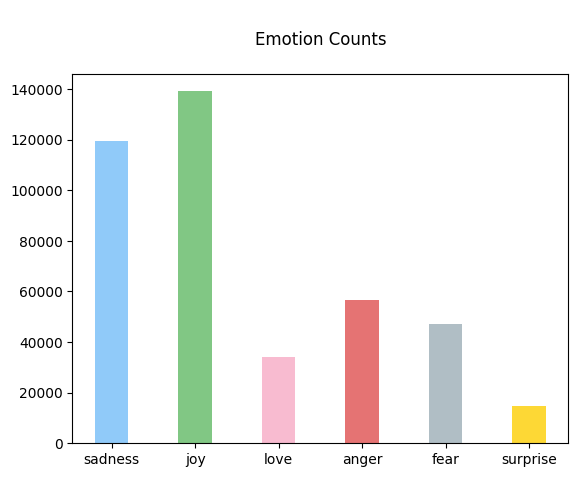

In [7]:
plot_emotion_dist(labels)

# Visualising the distribution of Emotions in the selected subset of 50K records

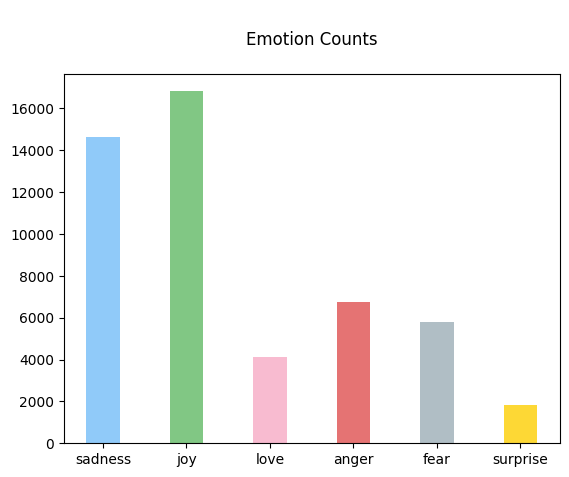

In [8]:
plot_emotion_dist(labels[:50000])

# Using first 50000 Records from the Dataset

Since there is no visible variation of Emotion Distribution in the 50K Subset of the Dataset, it can easily be used as a proxy for the full Emotion Dataset in this exercise of using it for a Multi-class Text Classification using Transformer. 

# Imbalanced classification data

It can be seen that the Dataset is imbalanced. The emotions of ```surprise``` and ```love``` closely followed by ```fear``` and ```anger``` are minority classes. However, since in the real-world Class proportions cannot be guranteed to not be skewed, it is a good exercise to find out how a Transformer Model coded from scratch performs in this task.

In [9]:
statements_50k = text_statements[:50000]
labels_50k = labels[:50000]

# Byte Pair Encoding of Emotion Dataset Statements

Byte Pair Encoding (BPE) algorithm, a popular method for subword tokenization. This section reuses code from Assignment 3.2C to extract Byte Pair Tokens from the dataset vocabulary to be used for feeding tokenised input to the Transformer. 

In [10]:
def get_all_statements(statements):
    all_statements = " ".join(statements)
    return all_statements
    
def clean_and_normalize_text(text):
    text = text.lower()
    translator = str.maketrans("", "", string.punctuation)
    cleaned_text = text.translate(translator)
    return cleaned_text

def calculate_token_frequencies_and_vocabulary(text):
    # Create a dictionary to store token frequencies
    token_frequency = {} 
    vocabulary = set()
    words = text.split()
    for word in words:
        word += "_"
        characters = list(word)
        chars_with_spaces = ""
        word_len = len(word)
        counter = 0
        for character in characters:
            vocabulary.add(character)
            chars_with_spaces += character
            counter += 1
            if counter < word_len:
                chars_with_spaces += " "

        if chars_with_spaces in token_frequency:
            token_frequency[chars_with_spaces] += 1
        else:
            token_frequency[chars_with_spaces] = 1
    return token_frequency, vocabulary

def calculate_most_frequent_symbol_pair(data):
    best_pair = ()
    frequency = 0
    pair_frequency = {}
    for word, freq in data.items():
        char_groups = word.split()
        group_len = len(char_groups)
        counter = 0
        while counter < group_len - 1:
            current = char_groups[counter]
            next = char_groups[counter+1]
            pair = (current, next)
            spaced_tuple = ' '.join(pair)
            if spaced_tuple in word:
                if pair in pair_frequency:
                    pair_frequency[pair] += freq
                else:
                    pair_frequency[pair] = freq
            counter += 1
    
    sorted_pairs_by_freq = sorted(pair_frequency.items(), key=lambda x:x[1], reverse=True)
    top_pair_freq = sorted_pairs_by_freq[0]
    best_pair = top_pair_freq[0]
    frequency = top_pair_freq[1]   
    return best_pair, frequency

def merge_symbol(pair, data, vocabulary):
    # Merge occurrences of the pair into a single symbol
    updated_data = {}
    spaced_tuple = ' '.join(pair)
    new_symbol = ''.join(pair)
    updated_vocabulary = vocabulary
    for word in data:
        pattern_1 = " "+spaced_tuple+" "
        pattern_2 = spaced_tuple+" "
        pattern_3 = " "+spaced_tuple
        exists = (pattern_1 in word) or (word.startswith(pattern_2)) or (word.endswith(pattern_3)) or (word == spaced_tuple)
        if exists:
            merged = word.replace(spaced_tuple, new_symbol)
            updated_data[merged] = data[word]
            updated_vocabulary.add(new_symbol)
        else:
            updated_data[word] = data[word]
 
    return updated_data, updated_vocabulary, new_symbol

def bpe(data, vocabulary, num_merges):
    merge_rules = []
    updated_data = data
    updated_vocabulary = vocabulary 
    for n in range(num_merges):
        best_pair, frequency = calculate_most_frequent_symbol_pair(updated_data)
        updated_data, updated_vocabulary, new_symbol = merge_symbol(best_pair, updated_data, updated_vocabulary)
    
        left = ' '.join(best_pair)
        merge_rules.append((left, new_symbol))
    return updated_data, updated_vocabulary, merge_rules

def build_token_indices(vocabulary):
    token_indices = {"<pad>": 0, "<bos>": 1, "<eos>": 2, "<oov>": 3}
    token_indices.update({key:index+4 for index, key in enumerate(vocabulary)})
    return token_indices

def token_segmenter(text, merge_rules):
    text = clean_and_normalize_text(text)
    tokenized_text = []
    
    token_frequency, vocabulary = calculate_token_frequencies_and_vocabulary(text)
    tokens = list(token_frequency.keys())

    for rule_pair in merge_rules:
        rule = rule_pair[0]
        merge = rule_pair[1]

        for idx, token in enumerate(tokens):
            new_token = token
            chars = new_token.split()
            if len(chars) == 1:
                continue

            i = 0
            word = []

            while i < len(chars) - 1:
                pair = chars[i] + " " + chars[i+1]
                if rule == pair:    
                    word.append(merge)
                    if i + 2 == len(chars) - 1:
                        word.append(chars[i+2])
                    
                    i += 2
                    continue
                    
                else:
                    word.append(chars[i])
                    if i == len(chars) - 2:
                        word.append(chars[i+1])
                    
                i += 1
                
            new_token = " ".join(word)
            tokens[idx] = new_token

    for token in tokens:
        tokenized_text.extend(token.split())
    return tokenized_text

In [11]:
# BPE Token Generation Pipeline
all_statements = get_all_statements(statements_50k)
cleaned_text = clean_and_normalize_text(all_statements)
data, vocabulary = calculate_token_frequencies_and_vocabulary(cleaned_text)
updated_data, updated_vocabulary, merge_rules = bpe(data, vocabulary, 1200)

In [12]:
token_indices = build_token_indices(updated_vocabulary)

# Custom PyTorch Dataset and DataLoaders with Collator function for Training, Validation, and Testing Data

To better decouple (in the interest of readability/modularity) the code for processing Emotion Data from Model training code, the data primitives ```Dataset``` and ```DataLoader``` (from ```torch.utils.data```) are used.

The Dataset is split in ratio of 80%, 10%, and 10% for Training, Validation, and Testing sets respectively. For a total number of 50000 Records that is then equal to 40000, 5000, and 5000 records. The Training and Validation sets are used for Training in batch sizes of 80 and 40 respectively, while the Training set has a batch of 40. 

The ```collator``` function pads the individual sequences to the longest sequence in a batch.

In [13]:
class TorchDataset(Dataset):
    def __init__(self, tokenised_sentences, labels):
        super().__init__()
        self.tokenised_sentences = tokenised_sentences
        self.labels = labels
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, index):
        tokenised_sentence = self.tokenised_sentences[index]
        label = self.labels[index]
        item = {"tokenised_sentence": tokenised_sentence, "labels": label} 
        return item 

In [14]:
def collator(batch):
    maxlen = 0
    index = -1
    maxindex = -1
    for items in batch:
        token_len = len(items['tokenised_sentence'])
        index += 1
        if token_len > maxlen:
            maxlen = token_len
            maxindex = index
            
    tokenised_ids, ignore_pad_mask, labels = [], [], []
    for items in batch:
        sentence = copy.deepcopy(items['tokenised_sentence'])
        token_len = len(sentence)
        mask = [1] * token_len
        if token_len < maxlen:
            padding = [token_indices["<pad>"]] * (maxlen - token_len)
            sentence.extend(padding)
            mask.extend(padding)

        tokenised_ids.append(sentence)
        ignore_pad_mask.append(mask)
        labels.append(items['labels'])

    tensorised_batch = {}
    tensorised_batch["tokens"] = torch.tensor(tokenised_ids, dtype=torch.int64)
    tensorised_batch["masks"] = torch.tensor(ignore_pad_mask, dtype=torch.int64)
    tensorised_batch["labels"] = torch.tensor(labels, dtype=torch.int64)
        
    return tensorised_batch

In [15]:
def get_tokenised_statements(statements):
    tokenised_statements = []
    for statement in statements:
        tokens = token_segmenter(statement, merge_rules)
        token_ids = [token_indices["<bos>"]]
        token_ids.extend([token_indices[token] for token in tokens])
        token_ids.extend([token_indices["<eos>"]])
        tokenised_statements.append(token_ids)
    return tokenised_statements

In [16]:
def get_dataloaders(tokenised_statements, labels, split=(80, 10, 10)):
    num_statements = len(tokenised_statements)
    training_index = math.floor(num_statements * (split[0]/100))
    validation_index = math.floor(num_statements * (split[1]/100)) + training_index
    
    train_dataset = TorchDataset(tokenised_statements[:training_index], labels[:training_index])
    valid_dataset = TorchDataset(tokenised_statements[training_index:validation_index], labels[training_index:validation_index])
    test_dataset = TorchDataset(tokenised_statements[validation_index:num_statements], labels[validation_index:num_statements])
    
    training = DataLoader(train_dataset, batch_size=80, shuffle=True, collate_fn=collator)
    validation = DataLoader(valid_dataset, batch_size=40, collate_fn=collator)
    testing = DataLoader(valid_dataset, batch_size=40, collate_fn=collator)

    return training, validation, testing

In [17]:
tokenised_statements = get_tokenised_statements(statements_50k)

In [18]:
training, validation, testing = get_dataloaders(tokenised_statements, labels_50k)

# Transformers

Transformers Models (Vaswani et al., 2017) learn the context by tracking relationships in sequential data, e.g. words in a given sentence. The Models use a mathematical technique called Attention or Self-Attention, to detect subtle ways in which distant words in a sentence (data elements in a sequence) influence each other and often times depend on each other.  

# Encoder-only Transformer

While the Transformer architecture proposed in the original paper (Vaswani et al., 2017) had a combination of Encoder and Decoder, due to the nature of the task at hand, i.e., Multi-class Text Classification, the Transformer Architecture for the Task is an **Encoder-only Transformer**. It is a simplified version of the original architecture incorporating a MultiHead Attention mechanism. The primary objective of Encoder-only Transformer Models seem to be extracting meaningful context from input sentences (data sequences). The context-rich representation space that is obtained as an output of Encoders, using the Attention mechanism, provides the capability required for understanding the semantics and nuances in an input sequence (sentence), that fits the use case of Multi-class Text Classification of Emotion expressed in a sentence.

# Embedding

Embedding as the name suggests, performs the role of ```Input Embedding``` by converting the tokenised input indices into vectors of d_model dimensions. These embeddings are multiplied by square root of d_model to prevent them from becoming very small values.

In [19]:
class Embedding(nn.Module):
    def __init__(self, n_tokens, d_model):
        super().__init__()
        self.n_tokens = n_tokens
        self.d_model = d_model
    
        self.embedding = nn.Embedding(n_tokens, d_model)
    
    def forward(self, input):
        return self.embedding(input) * math.sqrt(self.d_model)

# Layer Normalization

The LayerNormalization class, performs the role of ```Add & Norm``` block by normalizing the input data. The Layer Normalization (Ba, Kiros and Hinton, 2016) normalizes all features of inputs to a layer. This kind of Normalization is a step up from Batch Normalization that had dependence on batches, making Layer Normalization quite suitable for sequence models. The input data is subtracted from the arithmetic mean and divided by the standard deviation, resulting in a normalized output with a mean 0 and a standard deviation 1. A small number (epsilon) is added to the denominator to avoid  division by zero error.

The normalized input is then scaled by a learnable parameter alpha and add a learnable parameter bias.

In [20]:
class LayerNormalization(nn.Module):
    def __init__(self, epsilon=10**-6):
        super().__init__()
        self.epsilon = epsilon # guard against division by zero
        self.alpha = nn.Parameter(torch.ones(1))
        self.bias = nn.Parameter(torch.zeros(1))
    
    def forward(self, input):
        mean = input.mean(dim = -1, keepdim = True)
        std = input.std(dim = -1, keepdim = True)
        normalised_input = self.alpha * (input - mean) / (std + self.epsilon) + self.bias
        return normalised_input

# Positional Encoding


The PositionalEncoding class, performs the role of ```Positional Encoding```. It's role is to inject a (relative or absolute) position information of each token in an Input sequence. It uses sinusoidal functions - ```sine``` and ```cosine``` of different frequencies to generate the positional encoding due to their unique and smooth encoding tendencies. These sine and cosine functions are quite effective because a shift in the input would result in a predictable shift in the output, thus enabling the model to ascertain the position of an input token based on the position of other tokens in the sequence guided by the input token's offset. 

Due to the fact that Positional Encoder shares the same dimension ```d_model``` as the Embedding, these two vectors are easily summed, which in turn enriches the semantic content with a combination of embeddings and positional information.

In [21]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_len):
        super().__init__()
        self.dropout = nn.Dropout(p=0.1)
          
        # Creating a tensor representing positions
        position = torch.arange(max_seq_len).unsqueeze(1)
        # the division term
        divison = torch.exp((torch.arange(0, d_model, 2).float()) * (-math.log(10000.0) / d_model))
        
        postional_encoder = torch.zeros(1, max_seq_len, d_model)
        # for even indices - applying sin
        postional_encoder[0, :, 0::2] = torch.sin(position * divison)
        # for odd indices - applying cos
        postional_encoder[0, :, 1::2] = torch.cos(position * divison)
        
        # registering 'postional_encoder' as buffer 
        # since it doesn't need to be trained by the optimizer 
        self.register_buffer('postional_encoder', postional_encoder)

    def forward(self, input):
        pos_encoder = self.postional_encoder[:, :input.size(1), :]
        input_with_pos = input + pos_encoder
        input_with_pos = self.dropout(input_with_pos)
        return input_with_pos

# MultiHead Attention


The MultiHead Attention is the most important component of the Transformer and is responsible for helping the Model understand complex relationships and patterns in the data. It derives its name of MultiHead due to multiple repetitions of the Self Attention mechanism, learning different Semantic meanings of Attention. The Attention module splits its query, key, and value parameters for the number of heads and passes each split independently through a separate head. All of these similar Attention calculations are then combined together to produce a final Attention score. This is called Multi-head attention and gives the Transformer greater power to encode multiple relationships and nuances for each input token.


On its initialisation (through ```__init__```) the MultiHeadAttention class defines the Transformation Matrices for query, key, value, and linear_transform (output). The actual computation gets executed through forward function, where the inputs ```q```, ```k```, and ```v``` are passed through Linear Transformations ```self.query```, ```self.key```, and ```self.value```.

Next, the Transformed ```q```, ```k```, and ```v``` are split into multiple heads using ```view```. Following this the ```attention``` method is called on the split heads. The ```attention``` method firstly calculates the Scaled Dot Product between ```query``` and ```key.T``` by matrix multiplying and then scaling by ```sqrt``` of ```d_k```. The result is the Similarity (or Relevance) Score output ```attn_scores```. Depending on whether a Mask (to ignore Padding) is applied, the method then masks out the specific values of the ```attn_scores```. 

After this a ```Softmax``` is applied on the ```attn_scores``` to convert them into Probabiliities that add up to 1.

The final ```attention_values``` are calculated by matrix-multiplication of the ```attn_weights``` with ```value``` matrix. Next, the results from each head are combined back into a single combined tensor which is then passed through an output Linear Transformation ```linear_transform```.

In [22]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_k, d_v, d_model, heads):
        super().__init__()

        # init dimensions
        self.d_k = d_k
        self.d_v = d_v
        self.heads = heads
        
        # linear layers for transforming inputs
        self.query = nn.Linear(d_model, d_k * heads)
        self.key = nn.Linear(d_model, d_k * heads)
        self.value = nn.Linear(d_model, d_v * heads)
        
        # perform linear transform
        self.linear_transform = nn.Linear(d_v * heads, d_model)

    @staticmethod
    def attention(query, key, value, mask):
        d_k = query.shape[-1]
        # Calculate attention scores
        attn_scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
        # if provided, apply mask to preventing attention in padding
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask[:, None, None, :] == 0, float('-inf'))

        # Softmax is applied to obtain attention probabilities
        attn_weights = attn_scores.softmax(dim=-1)
        
        # multiplying the attention weights by the value matrix 
        # to get the final values 
        attention_values = torch.matmul(attn_weights, value)
        return attention_values


    def forward(self, q, k, v, mask=None):
        q, k, v = self.query(q), self.key(k), self.value(v)
        # Reshape the input to split number of heads for Multihead attention 
        # bring the head to 2nd dimension
        query = q.view(q.shape[0], q.shape[1], self.heads, self.d_k).transpose(1, 2)
        key = k.view(q.shape[0], q.shape[1], self.heads, self.d_k).transpose(1, 2)
        value = v.view(q.shape[0], q.shape[1], self.heads, self.d_k).transpose(1, 2)

        # perform scaled dot-product attention
        attn = MultiHeadAttention.attention(query, key, value, mask)

        # Combine heads and apply output transformation
        # reverse the previous transpose and make contiguous to correct the strides
        input = attn.transpose(1, 2).contiguous().view(q.shape[0], q.shape[1], self.d_k * self.heads)
        # apply output transformation
        out = self.linear_transform(input)
        
        return out

# Encoder

The Encoder encapsulates a MultiHead Attention followed by a Feed-Forward Network. The Feed-Forward Network acts as the non-linearity layer. The idea is that each embedding is multiplied by a trainable matrix (obtained using nn.Linear) which increases its dimensionality from ```d_model``` to ```d_model * heads```. On the resulting vector, a ```ReLU``` activation function is applied, and then it is transformed back with another trainable matrix (nn.Linear) to the original ```d_model``` dimension. The Feed-Forward Network takes the output of the MultiHead Attention as an input and re-process the representation coming out of the MultiHead Attention with a non-linearity.

Another important feature is that the connections are residual. Therefore, the network doesn’t completely change the raw embedding, instead it adds what has been computed into it. It learns to change (enhance) the original representation instead of re-creating a new one. As a final step, Layer Normlization is applied.

In [23]:
class Encoder(nn.Module):
    def __init__(self, d_k, d_v, d_model, heads):
        super().__init__()

        self.attention = MultiHeadAttention(d_k, d_v, d_model, heads)

        # 2 LayerNormalizations
        self.norm_1 = LayerNormalization()
        self.norm_2 = LayerNormalization()
        
        linear_transform_1 = nn.Linear(d_model, d_model * heads)
        linear_transform_2 = nn.Linear(d_model * heads, d_model)
        relu = nn.ReLU()
        self.feed_fwd_net = nn.Sequential(linear_transform_1, relu, linear_transform_2, nn.Dropout(0.1))
        
        self.dropout = nn.Dropout(p=0.1)
    
    def forward(self, input, mask=None):
        query, key, value = input, input, input
        # invoking the multi-head attention
        attn_out = self.attention(query, key, value, mask)
        
        # attn_out is added to original input (residual connection)
        input_plus_attn = input + attn_out
        normed_out_1 = self.norm_1(input_plus_attn)
        normed_out_2 = self.norm_2(normed_out_1 + self.feed_fwd_net(normed_out_1))
        out = self.dropout(normed_out_2)
        return out

# Transformer


The Transformer contains ```N``` number of Encoder blocks or layers, as well as an Embedding layer in addition to the Positional Encoding for the inputs.

In [24]:
class Transformer(nn.Module):
    def __init__(self, n_tokens, max_seq_len, d_k, d_v, d_model, h, N, emotions):
        super().__init__()
        self.embedding = Embedding(n_tokens, d_model)
        dropout = 0.1
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len)
        
        encoders = [] 
        for _ in range(N):
            encoder = Encoder(d_k, d_v, d_model, h)
            encoders.append(encoder)
        self.encoders = nn.Sequential(*encoders)
        
        self.norm = LayerNormalization()
        self.linear_transform = nn.Linear(d_model, emotions)

    def forward(self, input, mask=None):
        input_with_pos = self.pos_encoding(self.embedding(input))
        for encoder in self.encoders:
            out = encoder(input_with_pos, mask)
        out = self.linear_transform(self.norm(out[:, 0, :]))
        return out

# Multi-class Text Classification using the Transformer


The ```EmotionClassifier``` class performs the Multi-class Text Classification using the Transformer Model. The various network parameters it uses and their values are as follows:

- ```d_k = 8``` (dimension of each attention head's key and query vectors)
- ```d_v = 8``` (dimension of each attention head's value vectors)
- ```d_model = 32``` (dimension of the input representations)
- ```h = 4``` (number of attention heads)
- ```N = 2``` (number of encoders)

The ```EmotionClassifier``` class also provides ```fit``` method used for Training and ```test``` method for Testing with the ```testing``` dataset.

While Training the optimizer used is ```AdamW``` that enabled achieving better minimisation of the loss function and enhanced accuracy than with default ```Adam``` optimizer.

In [25]:
class EmotionClassifier():
    def __init__(self, num_tokens, max_seq_len=256, emotions=6, **kwargs):
        self.num_tokens = num_tokens
        self.seq_len = max_seq_len
        self.emotions = emotions
        
        self.d_k = kwargs.get("d_k", 8)
        self.d_v = kwargs.get("d_v", 8)
        self.d_model = kwargs.get("d_model", 32)
        self.h = kwargs.get("h", 4)
        self.N = kwargs.get("N", 2)

        self.transformer_model = Transformer(self.num_tokens, 
                                     self.seq_len, 
                                     self.d_k, self.d_v, self.d_model, self.h, self.N, 
                                     self.emotions)

    def fit(self, training_set, validation_set, num_epochs):
        loss_criterion = nn.CrossEntropyLoss()
        adam_optimizer = torch.optim.AdamW(self.transformer_model.parameters())
        avg_train_losses = [0] * num_epochs
        training_accuracies = [0] * num_epochs
        avg_valid_losses = [0] * num_epochs
        validation_accuracies = [0] * num_epochs

        for epoch in range(num_epochs):
            # Set the model in training mode
            self.transformer_model.train()
            training_loss = 0
            statements_trained = 0
            training_accurate_predictions = 0
            training_labels = 0
            validation_loss = 0
            statements_validated = 0
            validation_accurate_predictions = 0
            validation_labels = 0
            
            for minibatch in training_set:
                adam_optimizer.zero_grad()
                fwd_pass_outputs = self.transformer_model(minibatch['tokens'], minibatch['masks'])
                
                _, predicted_labels = torch.max(fwd_pass_outputs, 1)
                accurate = (predicted_labels == minibatch['labels'])
                training_accurate_predictions += accurate.sum().item()
                training_labels += minibatch['labels'].size(0)
                
                output = loss_criterion(fwd_pass_outputs, minibatch['labels'])
                

                output.backward()
                adam_optimizer.step()
                loss = output.item()
                training_loss += loss * minibatch['tokens'].size(0)
                statements_trained += minibatch['tokens'].size(0)


            # Set the model in evaluation mode
            self.transformer_model.eval()

            for minibatch in validation_set:
                outputs = self.transformer_model(minibatch['tokens'], minibatch['masks'])
                
                _, predicted_labels = torch.max(outputs, 1)
                accurate = (predicted_labels == minibatch['labels'])
                validation_accurate_predictions += accurate.sum().item()
                validation_labels += minibatch['labels'].size(0)
                
                loss_output = loss_criterion(outputs, minibatch['labels'])
                validation_loss += loss_output.item() * minibatch['tokens'].size(0)
                statements_validated += minibatch['tokens'].size(0)
            

            avg_train_losses[epoch] = training_loss / statements_trained
            avg_valid_losses[epoch] = validation_loss / statements_validated
            training_accuracies[epoch] = training_accurate_predictions / training_labels
            validation_accuracies[epoch] = validation_accurate_predictions / validation_labels
            print(f'Epoch {epoch + 1}, Training Loss: {avg_train_losses[epoch]}, Validation Loss: {avg_valid_losses[epoch]}')

        history = {"training_losses": avg_train_losses, "validation_losses": avg_valid_losses, 
                   "training_accuracies": training_accuracies, "validation_accuracies": validation_accuracies}
        
        return history

    def test(self, testing_set):
        self.transformer_model.eval()
        testing_accurate_predictions = 0
        testing_labels = 0
        preds = []
        truth = []
        for minibatch in testing_set:
            outputs = self.transformer_model(minibatch['tokens'], minibatch['masks'])
            
            _, predicted_labels = torch.max(outputs, 1)
            preds.append(predicted_labels)
            truth.append(minibatch['labels'])
            accurate = (predicted_labels == minibatch['labels'])
            testing_accurate_predictions += accurate.sum().item()
            testing_labels += minibatch['labels'].size(0)
            
        testing_accuracy = testing_accurate_predictions / testing_labels
        
        testing_metrics = {"accuracy": testing_accuracy, "preds": preds, "truth": truth}
        return testing_metrics

In [26]:
def get_num_tokens():
    num_special_tokens = 4
    num_tokens = len(updated_vocabulary) + num_special_tokens
    return num_tokens

# Model Training

In [30]:
emotion_classifier = EmotionClassifier(get_num_tokens())

In [32]:
history = emotion_classifier.fit(training, validation, 50)

Epoch 1, Training Loss: 1.4452049958705901, Validation Loss: 1.3712848224639893
Epoch 2, Training Loss: 1.3697461378574372, Validation Loss: 1.3109502582550048
Epoch 3, Training Loss: 1.3025218958854676, Validation Loss: 1.2341442770957947
Epoch 4, Training Loss: 1.2374406452178954, Validation Loss: 1.153566752910614
Epoch 5, Training Loss: 1.1746481778621674, Validation Loss: 1.0720947527885436
Epoch 6, Training Loss: 1.1176972012519837, Validation Loss: 1.0295856161117554
Epoch 7, Training Loss: 1.0782943426370621, Validation Loss: 1.0064620428085327
Epoch 8, Training Loss: 1.041832664489746, Validation Loss: 0.9893249497413635
Epoch 9, Training Loss: 1.0121270170211791, Validation Loss: 0.9598500204086303
Epoch 10, Training Loss: 0.9911139951944351, Validation Loss: 0.9293794341087341
Epoch 11, Training Loss: 0.9674928414821625, Validation Loss: 0.8995222353935242
Epoch 12, Training Loss: 0.9442696112394333, Validation Loss: 0.8922928371429444
Epoch 13, Training Loss: 0.932275898337

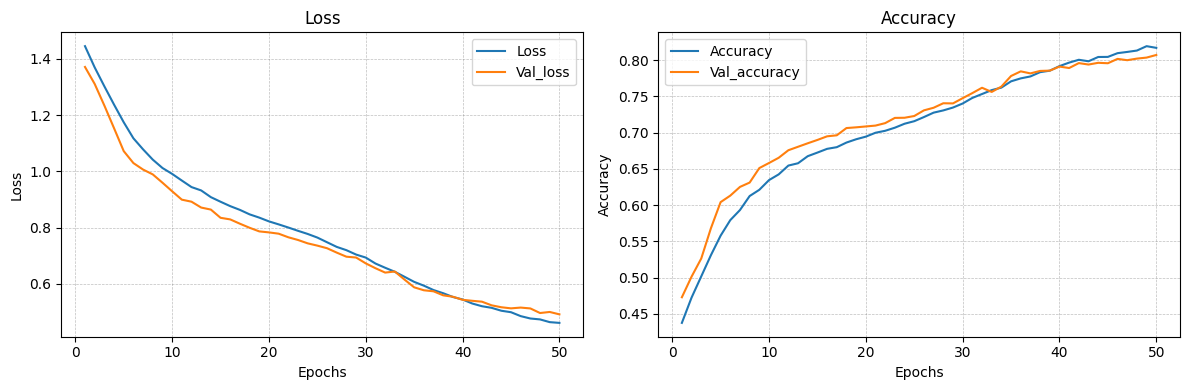

In [33]:
plt.figure(figsize=(12, 4))

ax1 = plt.subplot(1, 2, 1)
x = range(1, len(history['training_losses']) + 1)
plt.plot(x, history['training_losses'], label='Loss')
plt.plot(x, history['validation_losses'], label='Val_loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.legend()

ax2 = plt.subplot(1, 2, 2)
plt.plot(x, history['training_accuracies'], label='Accuracy')
plt.plot(x, history['validation_accuracies'], label='Val_accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# Transformer Model Evaluation

In [34]:
testing_metrics = emotion_classifier.test(testing)

In [35]:
def precision(emotion, y_true, y_pred):
    precision = 0
    tp = 0
    fp = 0
    for i in range(len(y_pred)):
        if y_true[i] == y_pred[i] == emotion:
            tp += 1
        if y_pred[i] == emotion and y_true[i] != y_pred[i]:
            fp += 1
    precision = (tp)/(tp + fp)
    return precision

def recall(emotion, y_true, y_pred):
    recall = 0
    tp = 0
    fn = 0
    for i in range(len(y_pred)):
        if y_true[i] == y_pred[i] == emotion:
            tp += 1
        if y_true[i] == emotion and y_true[i] != y_pred[i]:
            fn += 1
    recall = tp/(tp + fn)
    return recall


def f1_score(emotion, y_true, y_pred):
    f1_score = 0
    tp = 0
    fp = 0
    fn = 0
    for i in range(len(y_pred)):
        if y_true[i] == y_pred[i] == emotion:
            tp += 1
        if y_pred[i] == emotion and y_true[i] != y_pred[i]:
            fp += 1
        if y_true[i] == emotion and y_true[i] != y_pred[i]:
            fn += 1

    precision = (tp)/(tp+fp)
    recall = tp/(tp + fn)
    f1_score = 2 * ((precision * recall)/(precision + recall))
    return f1_score

In [36]:
def metrics_summary(metrics):
    accuracy = metrics["accuracy"]
    emotion_count = 6
    y_true = []
    y_pred = []
    pred_batches = len(metrics["preds"])

    for i in range(pred_batches):
        y_true.extend(metrics["truth"][i].tolist())
        y_pred.extend(metrics["preds"][i].tolist())

    
    table_1 = PrettyTable()
    table_1.field_names = ["Accuracy of the Model"]
    table_1.add_row([accuracy])
    
    table_2 = PrettyTable()
    table_2.field_names = ["Emotion", "Precision", "Recall", "F1-score"]
    table_2.align["Emotion"] = "l"
    for emotion in range(emotion_count):
        row = []
        row.append(emotions[emotion])
        row.append(precision(emotion, y_true, y_pred))
        row.append(recall(emotion, y_true, y_pred))
        row.append(f1_score(emotion, y_true, y_pred))
        table_2.add_row(row)

    print(table_1)
    print(table_2) 

In [37]:
metrics_summary(testing_metrics)

+-----------------------+
| Accuracy of the Model |
+-----------------------+
|         0.807         |
+-----------------------+
+----------+--------------------+--------------------+--------------------+
| Emotion  |     Precision      |       Recall       |      F1-score      |
+----------+--------------------+--------------------+--------------------+
| sadness  | 0.8292029470864032 | 0.8410326086956522 | 0.8350758853288365 |
| joy      | 0.8447742733457019 | 0.817474566128067  | 0.8309002433090025 |
| love     | 0.7030878859857482 | 0.7272727272727273 | 0.7149758454106281 |
| anger    | 0.7833827893175074 | 0.793984962406015  | 0.7886482449589247 |
| fear     | 0.7785123966942149 | 0.790268456375839  | 0.7843463780183181 |
| surprise | 0.7157894736842105 | 0.7195767195767195 | 0.7176781002638521 |
+----------+--------------------+--------------------+--------------------+


# Comparison with the Performance achieved in the Paper that introduced the Emotion Dataset
**(Saravia et al., 2018)**

![Performance Comparison in Original Paper](carer.png)

In [38]:
torch.save(emotion_classifier.transformer_model.state_dict(), "emotion_classifier_model.pt")

# Side-by-side comparison of F1-scores of various Emotions
(Please note that only a subset of Emotions were made available publicly for Research and Academic purposes only)

In [39]:
table_3 = PrettyTable()
table_3.field_names = ["Emotion", "CARER F1-score", "Custom Transformer F1-score"]
table_3.add_row(["anger", 0.74, 0.78])
table_3.add_row(["fear", 0.79, 0.78])
table_3.add_row(["joy", 0.83, 0.83])
table_3.add_row(["sadness", 0.82, 0.83])
table_3.add_row(["surprise", 0.76, 0.72])

print(table_3)

+----------+----------------+-----------------------------+
| Emotion  | CARER F1-score | Custom Transformer F1-score |
+----------+----------------+-----------------------------+
|  anger   |      0.74      |             0.78            |
|   fear   |      0.79      |             0.78            |
|   joy    |      0.83      |             0.83            |
| sadness  |      0.82      |             0.83            |
| surprise |      0.76      |             0.72            |
+----------+----------------+-----------------------------+


# Conclusion


As it can be seen from the above Side-by-side comparison table that the Custom Transformer coded from scratch using PyTorch is able to provide a comparable performance to a SOTA approach, although a bit dated (from 2018). This is a testament to the robust conceptual foundation of Transformers.

# References

Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A.N., Kaiser, L. and Polosukhin, I. (2017). Attention Is All You Need. [online] arXiv.org. doi:https://doi.org/10.48550/arXiv.1706.03762.


Saravia, E., Liu, H.-C.T., Huang, Y.-H., Wu, J. and Chen, Y.-S. (2018). CARER: Contextualized Affect Representations for Emotion Recognition. [online] ACLWeb. doi:https://doi.org/10.18653/v1/D18-1404.

Ba, J.L., Kiros, J.R. and Hinton, G.E. (2016). Layer Normalization. [online] arXiv. doi:https://doi.org/10.48550/arXiv.1607.06450.